In [1]:
import pandas as pd

# Load SOL CSV
sol_df = pd.read_csv(r'feature_datasets\SOL_features.csv', parse_dates=True, index_col=0)

# Define X and y
sol_y = sol_df['Close'].shift(-1)          # next-day close price
sol_X = sol_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
sol_X = sol_X.iloc[:-1]
sol_y = sol_y.iloc[:-1]

# Optional: check shapes
print("SOL X shape:", sol_X.shape)
print("SOL y shape:", sol_y.shape)

SOL X shape: (915, 29)
SOL y shape: (915,)


## Basis split 

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(sol_X) * 0.7)

sol_X_train = sol_X.iloc[:split_idx].values
sol_X_test  = sol_X.iloc[split_idx:].values

sol_y_train = sol_y.iloc[:split_idx].values
sol_y_test  = sol_y.iloc[split_idx:].values

print("ETH X_train shape:", sol_X_train.shape)
print("ETH X_test shape:", sol_X_test.shape)
print("ETH y_train shape:", sol_y_train.shape)
print("ETH y_test shape:", sol_y_test.shape)

ETH X_train shape: (640, 29)
ETH X_test shape: (275, 29)
ETH y_train shape: (640,)
ETH y_test shape: (275,)


In [3]:
sol_test_dates = sol_df.index[-len(sol_X_test):]

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
sol_X_train_scaled = scaler.fit_transform(sol_X_train)

# Transform TEST using the same scaler
sol_X_test_scaled = scaler.transform(sol_X_test)

# Check shapes
print("Scaled X_train shape:", sol_X_train_scaled.shape)
print("Scaled X_test shape:", sol_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [5]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
sol_y_train_scaled = y_scaler.fit_transform(sol_y_train.reshape(-1,1)).flatten()

# Scale test target
sol_y_test_scaled = y_scaler.transform(sol_y_test.reshape(-1,1)).flatten()


In [7]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for SOL using scaled target
sol_X_train_seq, sol_y_train_seq = create_sequences(sol_X_train_scaled, sol_y_train_scaled, time_steps=30)
sol_X_test_seq, sol_y_test_seq = create_sequences(sol_X_test_scaled, sol_y_test_scaled, time_steps=30)

# Check shapes
print("SOL X_train_seq shape:", sol_X_train_seq.shape)
print("SOL y_train_seq shape:", sol_y_train_seq.shape)
print("SOL X_test_seq shape:", sol_X_test_seq.shape)
print("SOL y_test_seq shape:", sol_y_test_seq.shape)

SOL X_train_seq shape: (610, 30, 29)
SOL y_train_seq shape: (610,)
SOL X_test_seq shape: (245, 30, 29)
SOL y_test_seq shape: (245,)


### Model training

In [8]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [9]:
# Get number of features from the sequences
input_size = sol_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)


In [10]:
model = train_model(model, sol_X_train_seq, sol_y_train_seq, epochs=50, batch_size=32, lr=0.001
)


Epoch [10/50], Loss: 0.002943
Epoch [20/50], Loss: 0.002920
Epoch [30/50], Loss: 0.001725
Epoch [40/50], Loss: 0.001409
Epoch [50/50], Loss: 0.007718


In [11]:
sol_preds = predict_model(model, sol_X_test_seq)

# check
print("Predictions shape:", sol_preds.shape)
print("First 10 predictions:", sol_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.06754614]
 [0.06083958]
 [0.05708154]
 [0.05274357]
 [0.05085738]
 [0.04962961]
 [0.04920836]
 [0.04708476]
 [0.03345165]
 [0.03602985]]


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
sol_preds_actual = y_scaler.inverse_transform(sol_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
sol_y_test_actual = sol_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(sol_y_test_actual, sol_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_y_test_actual, sol_preds_actual)
r2 = r2_score(sol_y_test_actual, sol_preds_actual)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")


MSE: 55.09
RMSE: 7.42
MAE: 6.16
R2 Score: 0.8978


In [13]:
sol_preds_actual = y_scaler.inverse_transform(sol_preds.reshape(-1,1))

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = sol_df.index[-len(sol_X_test):][30:]  # test dates aligned with sequences
actual_seq = sol_y_test[30:]                      # actual prices aligned
pred_seq = sol_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot.head()

,Actual,Predicted
Date,,
2023-05-02,22.264978,26.489855
2023-05-03,22.218002,24.818027
2023-05-04,21.730349,23.881214
2023-05-05,22.826111,22.799833
2023-05-06,21.974262,22.329639


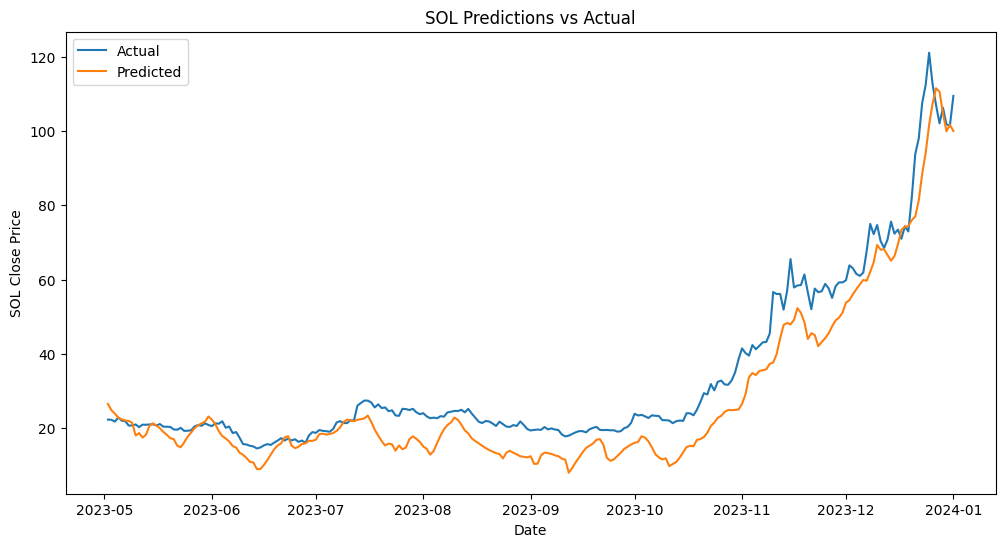

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% split

In [17]:
# Get unique years from your DataFrame index
years = sol_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [18]:
X_train_list = []
y_train_list = []

In [19]:
for year in years:
    # Filter data for this year
    sol_year = sol_df[sol_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(sol_year) * 0.7)

    # Take first 70% as training
    X_train_year = sol_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = sol_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [20]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)


Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [21]:
X_test_list = []
y_test_list = []

In [22]:
for year in years:
    sol_year = sol_df[sol_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(sol_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = sol_year.iloc[split_idx:, 1:].values   # features
    y_test_year = sol_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [23]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [24]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [25]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [26]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Model training 

In [27]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [29]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [30]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.004064
Epoch [20/50], Loss: 0.006435
Epoch [30/50], Loss: 0.005722
Epoch [40/50], Loss: 0.001578
Epoch [50/50], Loss: 0.003573


In [31]:
sol_preds_ev_year = predict_model(model_y, X_test_seq)
sol_preds_ev_year[:10]

array([[0.9582543 ],
       [0.9403538 ],
       [0.9278311 ],
       [0.92142636],
       [0.91398686],
       [0.870079  ],
       [0.8421181 ],
       [0.83847797],
       [0.84405416],
       [0.82062614]], dtype=float32)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
sol_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
sol_preds_actual = y_scaler.inverse_transform(sol_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
sol_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(sol_y_test_actual, sol_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_y_test_actual, sol_preds_actual)
r2 = r2_score(sol_y_test_actual, sol_preds_actual)

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")


MSE: 348.69
RMSE: 18.67
MAE: 9.77
R2 Score: 0.8595


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = sol_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_sol_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_sol_plot_year.head()


,Actual,Predicted
0,194.199219,237.477112
1,190.596909,233.227432
2,194.621704,230.254471
3,181.178085,228.733948
4,167.954834,226.967773


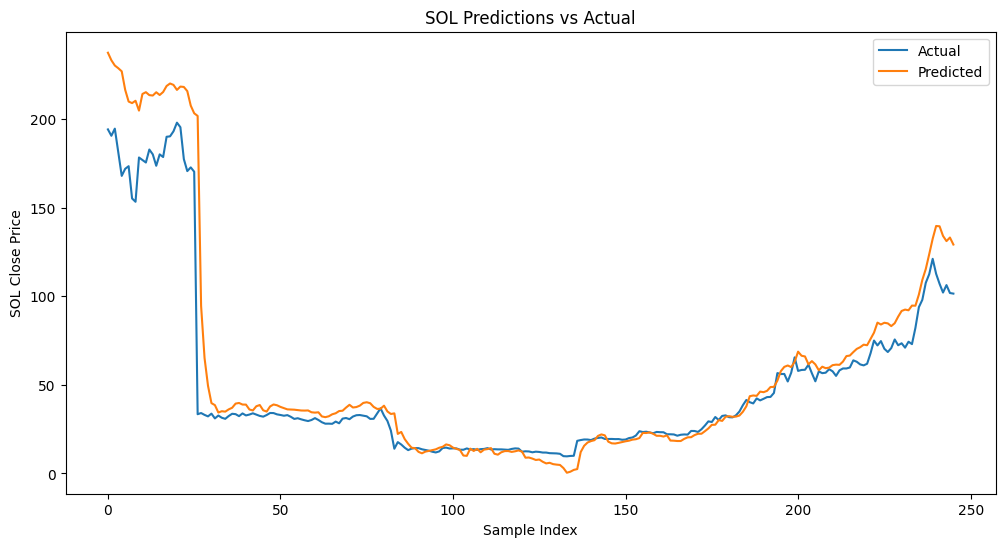

In [34]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_sol_plot_year["Actual"], label="Actual")
plt.plot(df_sol_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual")
plt.legend()
plt.show()
